

<font color=#009afa size=50>Air Quality</font>

<font size=50>DAT5003 - Applied Data Science</font>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan, ST20285213|
|**Course:**| DAT5003_S2_24|
|**Course Tutor:**| Dr. Angesh Anupam|


>This assignment is designed to assess your ability to formulate relevant and insightful analytic
questions based on your chosen dataset. You will need to process the data using key steps of (big)
data analytics, including data pre-processing, analysis, and the preparation of an analytical report.
Your analysis should address a significant issue that is valuable for stakeholders (e.g., policymakers,
businesses) to gain meaningful insights, rather than a trivial topic.


In this report, I will ...

[link text](https://)Research:

https://www.gov.uk/guidance/monitoring-ambient-air-data-analysis-techniques



| Abreviation | Chemical | Notes |
|---|---|---|
| C6H6 | Benzene | Found in petrol |
| NMHC | Non Metanic hydrocarbons | Ethane, ethene, acetylene, propane, propene and isoprene |



# Task 1

Task 1 – Analytic question
In this task, choose an analytic question. For your analysis to be compelling it must address a
substantive issue useful for the stakeholders (for example, policymakers, businesses) to draw insight
rather than a trivial one. Hence you must consider these aspects before choosing a question.

The analytic questions for Task 1 should be submitted in a .ipynb file. In addition to the questions, you
should provide a concise explanation of the rationale behind your chosen question and the expected
impact of answering it.


<font color=#009afa size=10>"It is possible to predict future pollution levels based on historical data to inform residents of the city about potentially risky times, and when to take precautions or avoid going outside without a mask?</font>

# Task 2 - Data Analysis


Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.

In [ ]:
# Import Standard Python Libraries
import os
import re
import json
from urllib import request
import math
import statistics
from cycler import cycler

# Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.

online = False
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://github.com',
                  'https://cardiffmet.ac.uk']

def check_internet(url_list):
    # We only need the first 200 code to prove a connection.
    for _url in url_list:
        try:
            request.urlopen(_url, timeout=3)
            return True
        except request.URLError as err:
            print (f"[Check Internet] Failed for {_url}")

if check_internet(_urls_to_check ) == True:
    print ("[Check Internet] Internet Connectivity Detected. Using Internet resources.")
    online = True
    url_prefix = "https://datascience.daemonchild.com/year2/dat5003/"

else:
    print ("[Check Internet] No Internet Connectivity. Using local resources.")
    url_prefix = "../"

[Check Internet] Internet Connectivity Detected. Using Internet resources.


In [ ]:
# Install Requirements Using Pip
#%pip install -r ../requirements.txt

In [ ]:
# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# SciKit Learn
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import r2_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import zscore
from sklearn import cluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Seaborn Graphs
import seaborn as sns

# Tabulate
from tabulate import tabulate

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

The data comes from: https://archive.ics.uci.edu/dataset/360/air+quality

In [ ]:
if online:
  df = pd.read_csv('https://archive.ics.uci.edu/static/public/360/data.csv')
else:
  df = pd.read_csv(url_prefix + 'air_quality_data.csv')

## Exploratory Data Analysis (EDA)

In [ ]:
print(df.head())
print (f"\n {40 * '-'}")
print(df.shape)
print (f"\n {40 * '-'}")
print(df.describe)

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  3/10/2004  18:00:00     2.6         1360       150      11.9   
1  3/10/2004  19:00:00     2.0         1292       112       9.4   
2  3/10/2004  20:00:00     2.2         1402        88       9.0   
3  3/10/2004  21:00:00     2.2         1376        80       9.2   
4  3/10/2004  22:00:00     1.6         1272        51       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0           1046      166          1056      113          1692         1268   
1            955      103          1174       92          1559          972   
2            939      131          1140      114          1555         1074   
3            948      172          1092      122          1584         1203   
4            836      131          1205      116          1490         1110   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.7502  
3  11.0  60.0  0.7867  
4 

According to the information found at the page hosted by [UC Irvine](https://archive.ics.uci.edu/dataset/360/air+quality) "missing values are tagged with -200 value."

The following code quickly explores how prevalent missing values are by counting '-200' throughout the data set. Which are the worst offending fields?

In [ ]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

In [ ]:
(df == -200).sum()

,0
Date,0
Time,0
CO(GT),1683
PT08.S1(CO),366
NMHC(GT),8443
C6H6(GT),366
PT08.S2(NMHC),366
NOx(GT),1639
PT08.S3(NOx),366
NO2(GT),1642


## Feature Engineering

Here I will use existing data to generate a number of useful features to allow further processing and analysis of the data set.

From the 'Date' and 'Time' fields, it is simple to create a combined 'Date-and-Time' ('Datetime') feature. It is equally simple to split out the 'Time' field into a simpler 'Hour' feature.

- Datetime
- Hour


In [ ]:
# Create 'Datetime'
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Create 'Hour' by splitting the Time field
# 13:00:00 -> 13
df['Hour'] = df['Time'].apply(lambda x: int(x.split(':')[0]))

Now I will extract lists of like features from the columns of the dataset:

In [ ]:
# Extract 'Ground True concentration' fields
gt_fields = [col for col in list(df.columns) if "GT" in col]

# Extract pt08 fields
pt08_fields = [col for col in list(df.columns) if "PT08" in col]

# List of atmospheric fields
atmos_fields = ['AH','RH','T']

Draw some exploratory graphs of each field in the GT field set.
(Note that '-200' denotes a missing value making the charts look very odd. This is therefore changed to zero for these exploratory plots.)

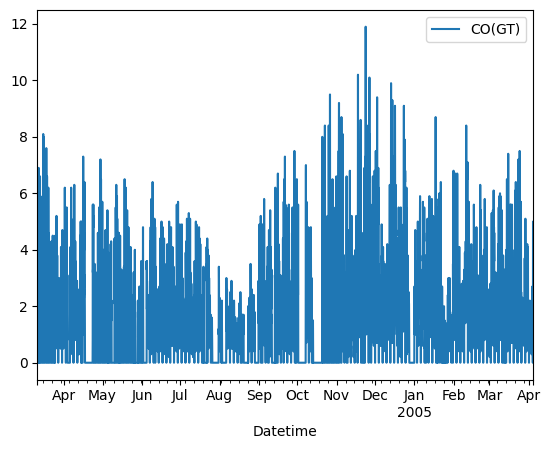

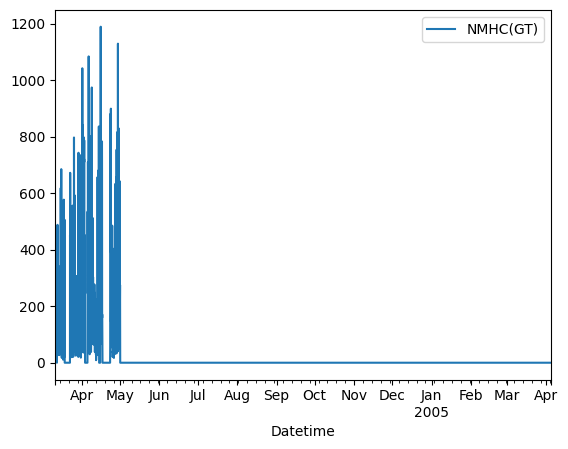

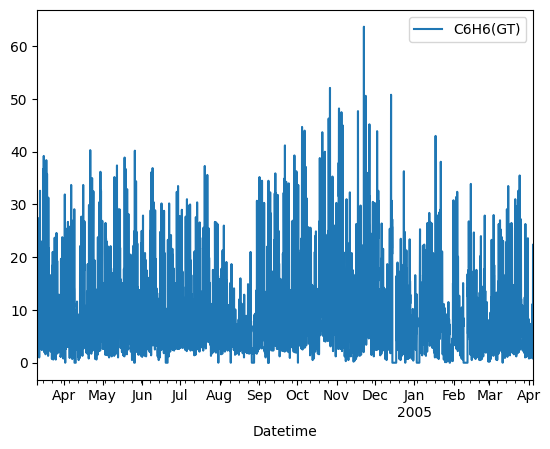

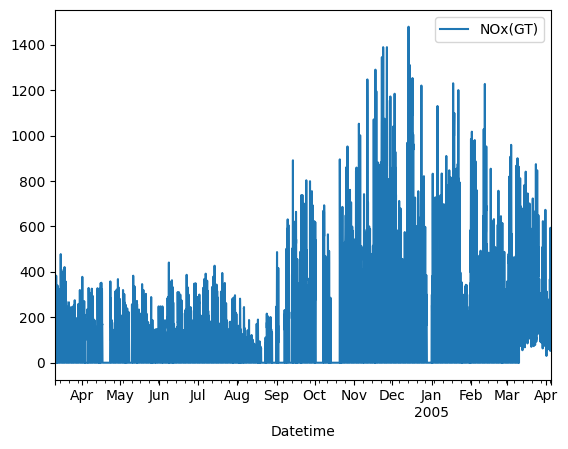

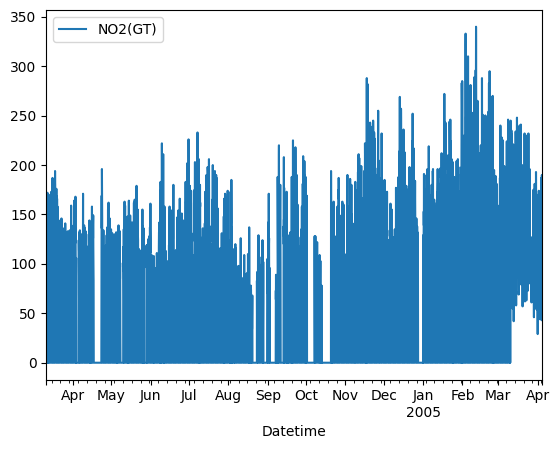

In [ ]:
for field in gt_fields:
  plot_df = df[['Datetime', field]]
  plot_df[field].replace(-200, 0, inplace=True)
  plot_df.plot(kind='line',x='Datetime', y=field)
  plt.show()


And the PT08 field set:

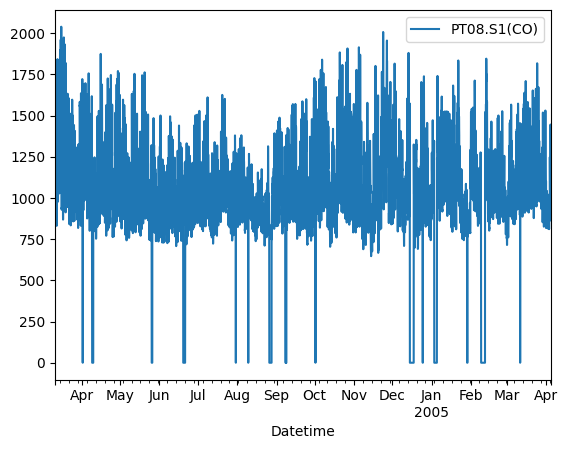

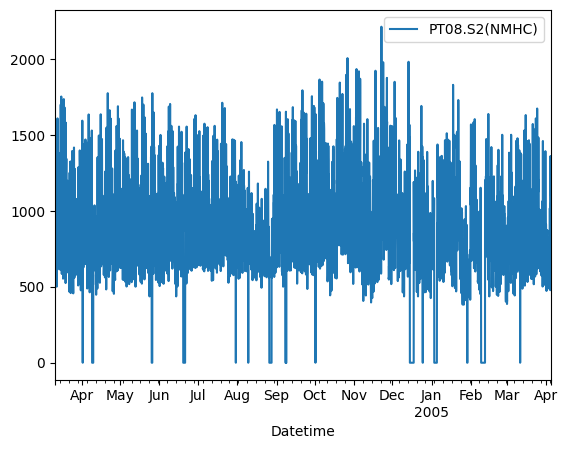

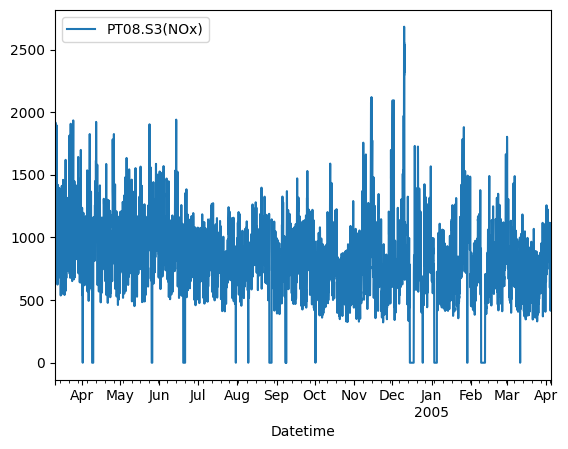

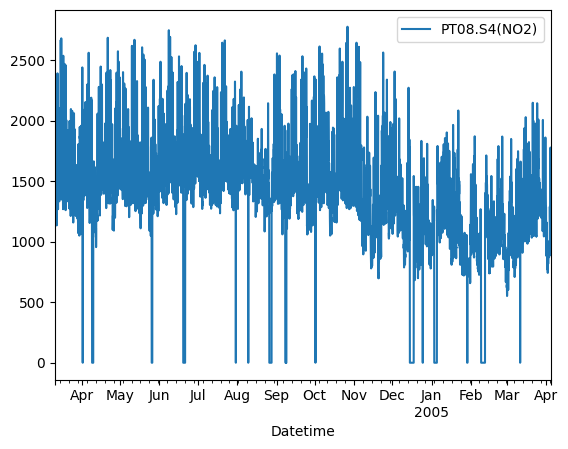

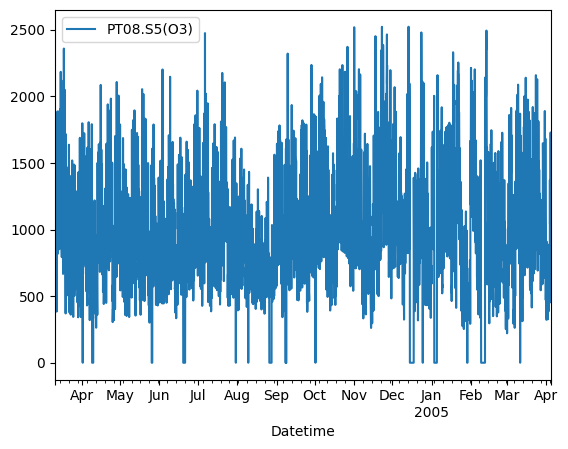

In [ ]:
for field in pt08_fields:
  plot_df = df[['Datetime', field]]
  plot_df[field].replace(-200, 0, inplace=True)
  plot_df.plot(kind='line',x='Datetime', y=field)
  plt.show()

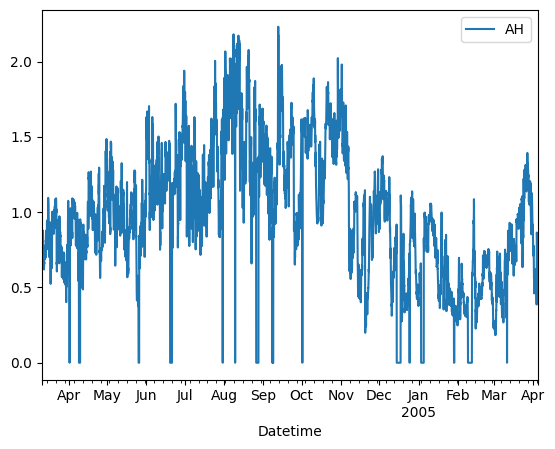

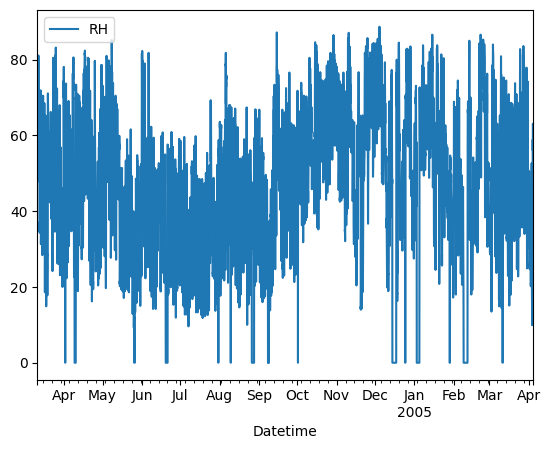

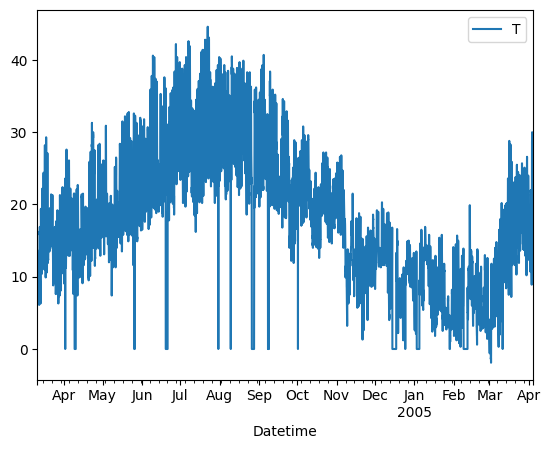

In [ ]:
for field in atmos_fields:
  plot_df = df[['Datetime', field]]
  plot_df[field].replace(-200, 0, inplace=True)
  plot_df.plot(kind='line',x='Datetime', y=field)
  plt.show()

Impute the missing values using K Nearest Neighbours

(https://scikit-learn.org/stable/modules/impute.html)

In [ ]:
# Optimise the value for the number of neighbours

from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error





In [ ]:
df.replace(-200, np.nan, inplace=True)

impute_fields = gt_fields + pt08_fields + atmos_fields

# Define the range of k values to test
k_values = {'n_neighbors': [1, 2, 3, 5, 7, 9, 11]}

# Initialize KNNImputer
knn_imputer = KNNImputer()

# Perform grid search with cross-validation
grid_search = GridSearchCV(knn_imputer, param_grid=k_values, cv=KFold(n_splits=5), scoring='neg_mean_squared_error')
grid_search.fit(df[impute_fields])

# Best k value
best_k = grid_search.best_params_['n_neighbors']
print(f"Optimal number of neighbors: {best_k}")







Optimal number of neighbors: 1


In [ ]:
neighbours = 1
# https://www.geeksforgeeks.org/how-to-find-the-optimal-value-of-k-in-knn/

imputer = KNNImputer(n_neighbors=neighbours, weights="uniform")
imputer.fit_transform(df[impute_fields])
df[impute_fields] = imputer.fit_transform(df[impute_fields])

Drawing a heatmap to show the correlation between these fields:

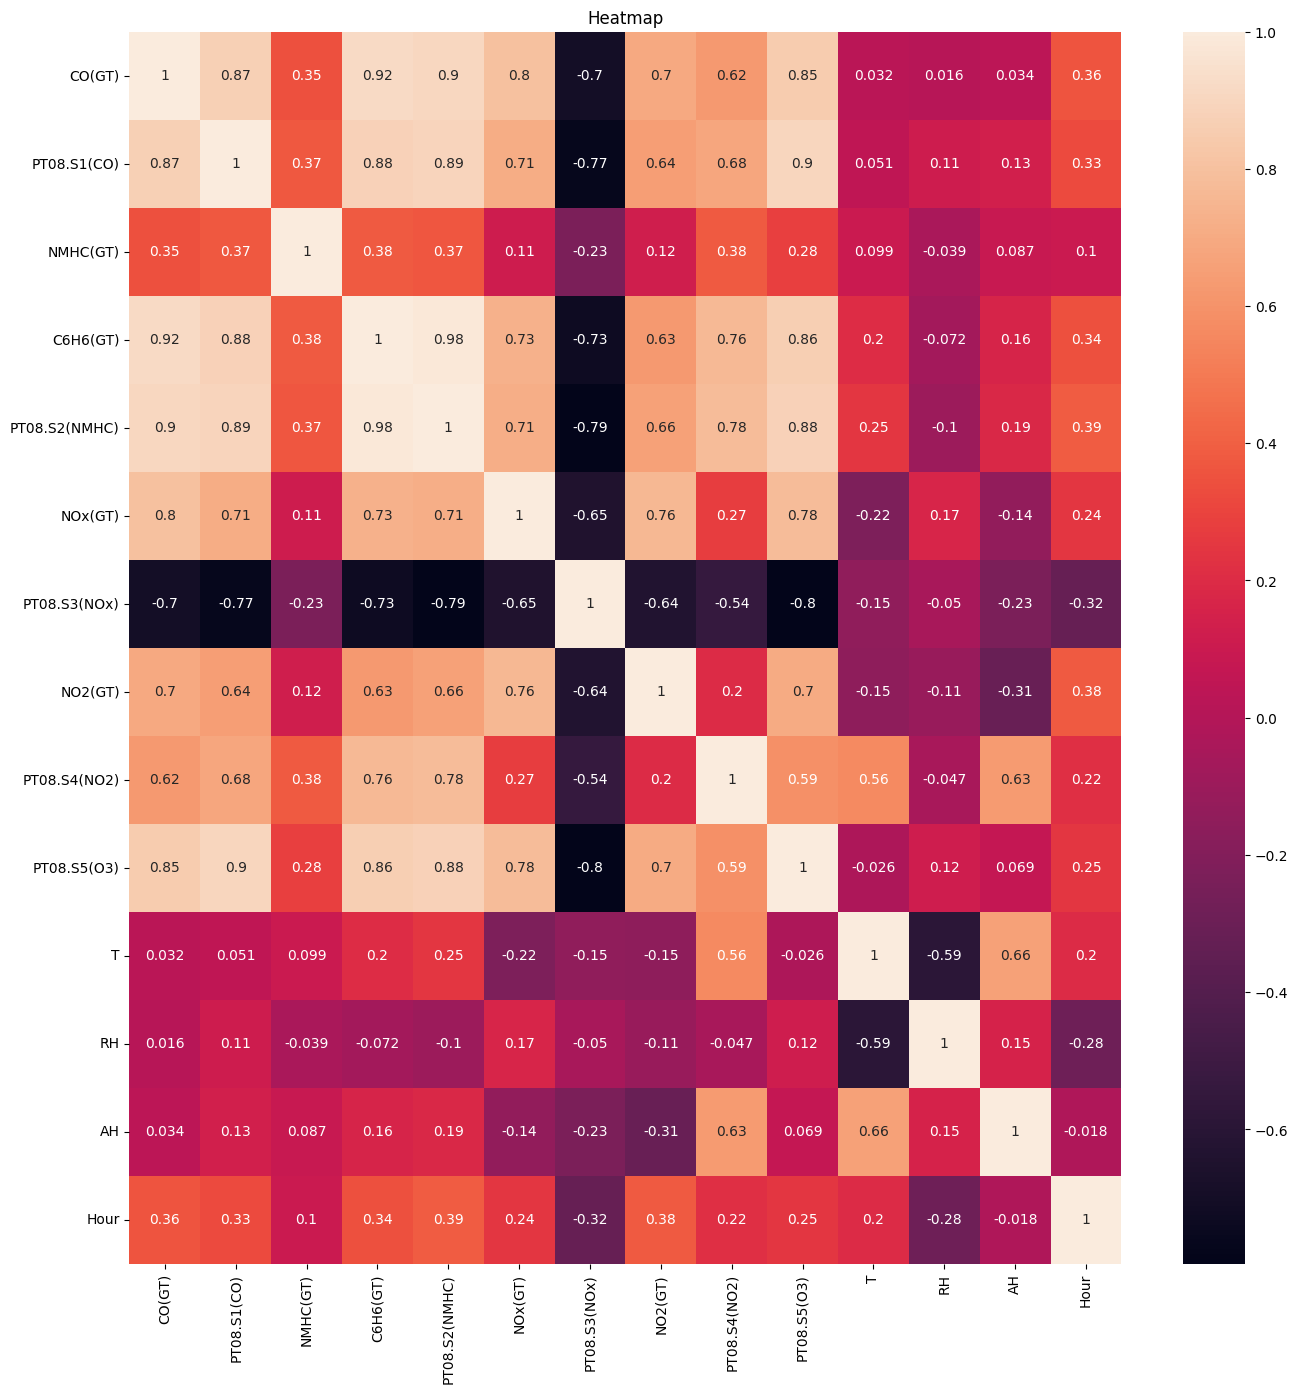

In [ ]:
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(16, 16))
sns.heatmap(numerical_df.corr(),annot=True)
plt.title('Heatmap')
plt.show()

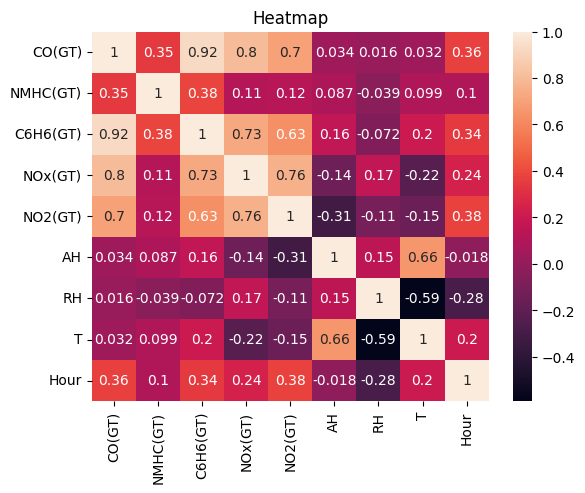

In [ ]:
numerical_df = df[gt_fields + atmos_fields + ['Hour']]
sns.heatmap(numerical_df.corr(),annot=True)
plt.title('Heatmap')
plt.show()

Redraw the exploratory graphs with imputed values:

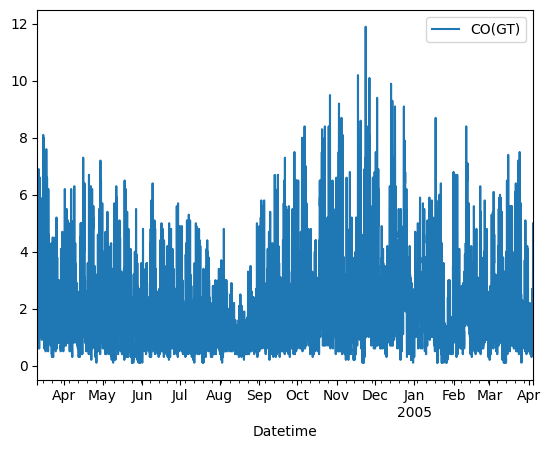

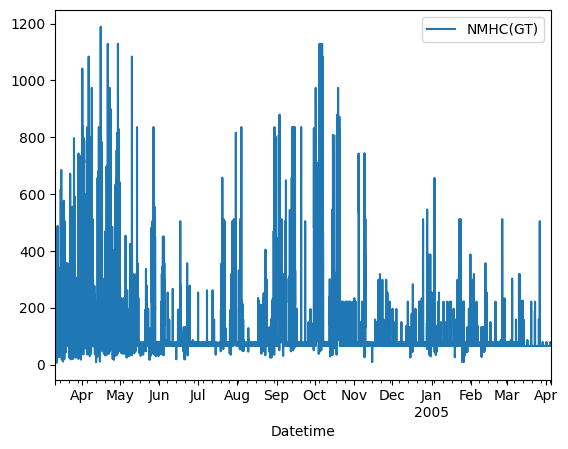

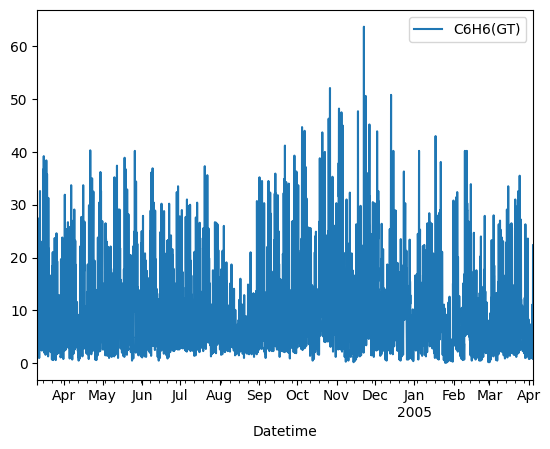

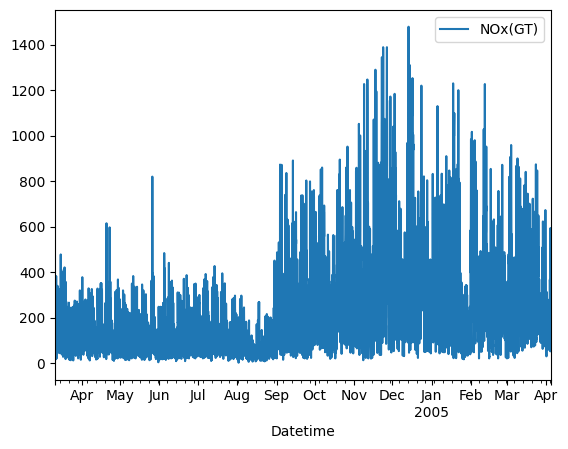

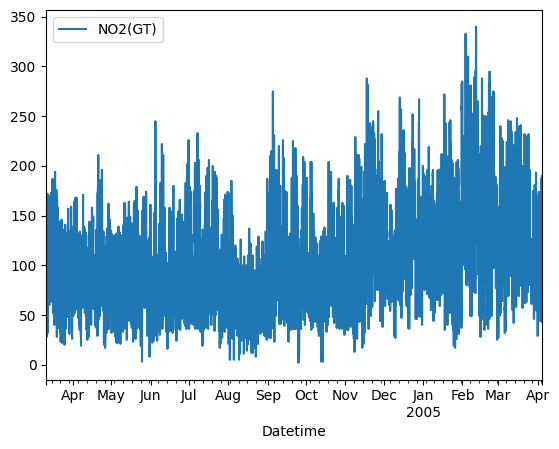

In [ ]:
for field in gt_fields:
  plot_df = df[['Datetime', field]]
  plot_df.plot(kind='line',x='Datetime', y=field)
  plt.show()

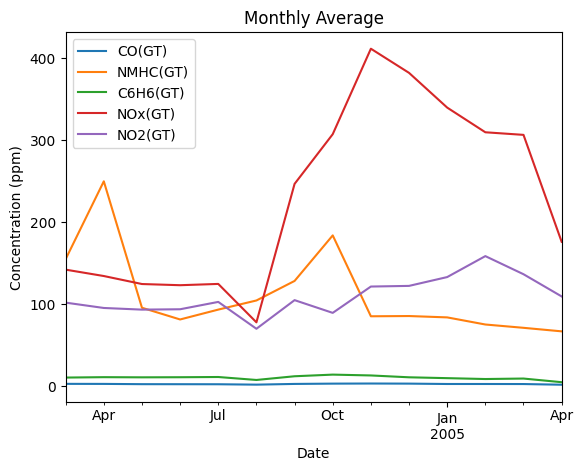

In [ ]:
df.reset_index(inplace=True)
df.set_index('Datetime', inplace=True)

for field in gt_fields:

  # Resample to Monthly frequency and calculate the mean
  daily_average = df[field].resample('M').mean()

  daily_average.plot(kind='line')
  plt.xlabel('Date')
  plt.ylabel('Concentration (ppm)')
  #plt.title(f'Monthly Average {field}')

plt.legend(gt_fields)
plt.title(f'Monthly Average')
plt.show()

df.reset_index(inplace=True)

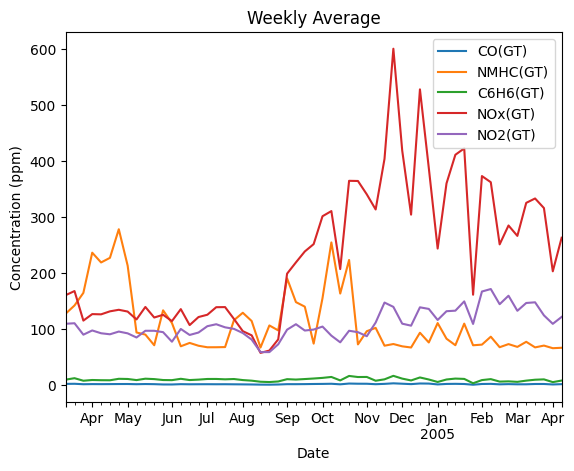

In [ ]:
df.set_index('Datetime', inplace=True)

for field in gt_fields:

  # Resample to Monthly frequency and calculate the mean
  daily_average = df[field].resample('W').mean()

  daily_average.plot(kind='line')
  plt.xlabel('Date')
  plt.ylabel('Concentration (ppm)')


plt.legend(gt_fields)
plt.title(f'Weekly Average')
plt.show()

df.reset_index(inplace=True)

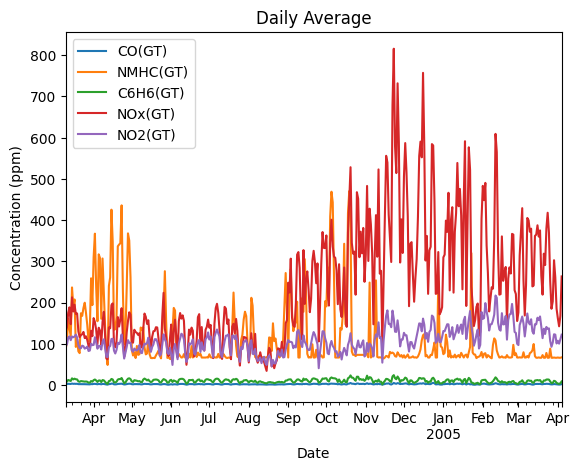

In [ ]:
df.set_index('Datetime', inplace=True)

for field in gt_fields:

  # Resample to Monthly frequency and calculate the mean
  daily_average = df[field].resample('D').mean()

  daily_average.plot(kind='line')
  plt.xlabel('Date')
  plt.ylabel('Concentration (ppm)')


plt.legend(gt_fields)
plt.title(f'Daily Average')
plt.show()

df.reset_index(inplace=True)